**Assignment-2**  
**Task:** Data cleaning, EDA, bias analysis, report.  
**Name:** Haseeb ur Rahman (23F-0566) & Zia ur Rehman (23F-0547)

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
from scipy.stats import mannwhitneyu

%matplotlib inline
plt.rcParams['figure.figsize'] = (10,6)
sns.set(style="whitegrid")

In [70]:
df = pd.read_csv("pakistan-media-dataset-synthetic.csv")
print("Original shape:", df.shape)
df.head()

Original shape: (15000, 22)


,ID,Journalist,Channel,Newspaper,Region,City,Topic,Headline,Ratings,Revenue,...,BiasScore,Viewership,Shares,AdSpend,ControversyFlag,MissingDataFlag,Date,Language,PoliticalAffiliation,SocialMediaInteractions
0,0,Najam Sethi,ARY News,The News,Islamabad,Multan,Sports,Polio cases reported in KPK,10.613151,11648570,...,NaN,1756573.0,136184.0,4452987.876,No,1.0,2021-06-21,English,Opposition,NaN
1,1,Dr. Shahid Masood,HUM News,Dawn,Sindh,Quetta,Crime,Budget deficit reaches record high,27.545705,5 million,...,5.0,1546170.0,NaN,1 crore,1,NaN,2019-11-19,urdu,NaN,14461.0
2,2,Kamran Shahid,Samaa,Jang,Sindh,Rawalpindi,Health,Attack on Army convoy in Waziristan,50.387473,14072656,...,NaN,NaN,NaN,50 lakh,Yes,NaN,2024-05-07,urdu,Pro-Govt,33436.0
3,3,Matiullah Jan,DawnNews,Nawa-i-Waqt,Islamabad,Multan,Health,Hospitals face medicine shortages,NaN,812673,...,2.0,1083972.0,16712.0,1 crore,1,NaN,2019-10-03,urdu,Neutral,NaN
4,4,RAUF KLASSRA,SAMAA TV,The News,Sindh,Karachi,Sports,Chief Justice orders suo moto on Karachi violence,NaN,NaN,...,NaN,700635.0,NaN,3975468.534,NaN,0.0,2018-02-07,Urdu,Neutral,NaN


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       15000 non-null  int64  
 1   Journalist               15000 non-null  object 
 2   Channel                  15000 non-null  object 
 3   Newspaper                15000 non-null  object 
 4   Region                   15000 non-null  object 
 5   City                     15000 non-null  object 
 6   Topic                    15000 non-null  object 
 7   Headline                 15000 non-null  object 
 8   Ratings                  7640 non-null   float64
 9   Revenue                  11919 non-null  object 
 10  Airtime                  7489 non-null   float64
 11  SentimentScore           7490 non-null   float64
 12  BiasScore                7445 non-null   float64
 13  Viewership               9996 non-null   float64
 14  Shares                

## check how many values are null in percentage

In [72]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

SocialMediaInteractions    50.400000
BiasScore                  50.366667
Airtime                    50.073333
SentimentScore             50.066667
Shares                     49.973333
Ratings                    49.066667
Viewership                 33.360000
MissingDataFlag            33.186667
PoliticalAffiliation       24.953333
AdSpend                    24.700000
Revenue                    20.540000
Language                   19.953333
ControversyFlag            19.553333
ID                          0.000000
City                        0.000000
Region                      0.000000
Newspaper                   0.000000
Channel                     0.000000
Journalist                  0.000000
Topic                       0.000000
Headline                    0.000000
Date                        0.000000
dtype: float64

## Make string columns in standard way

In [73]:
df['Channel'] = df['Channel'].str.strip().str.title()
df['Journalist'] = df['Journalist'].str.strip().str.title()
df['Region'] = df['Region'].str.strip().str.title()
df['City'] = df['City'].str.strip().str.title()
df['Topic'] = df['Topic'].str.strip().str.title()
df['Newspaper'] = df['Newspaper'].str.strip().str.title()
df['Headline'] = df['Headline'].str.strip()
df['Language'] = df['Language'].str.strip().str.title()
df['PoliticalAffiliation'] = df['PoliticalAffiliation'].str.strip().str.title()

In [74]:
def normalize_text(s):
    if pd.isna(s): 
        return s
    s = str(s).strip()
    s = re.sub(r'\s+', ' ', s)
    return s

def to_lower_strip(s):
    if pd.isna(s): 
        return s
    return str(s).lower().strip()

def parse_money_to_pkr(value):
    #Convert strings like '5 million', '50 lakh', '1 crore', '4,452,987.876' to float PKR
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    s = str(value).lower().strip().replace(',', '')
    try:
        return float(s)
    except:
        pass
    if 'crore' in s:
        num = re.findall(r'[\d\.]+', s)
        if num:
            return float(num[0]) * 10_000_000
    if 'lakh' in s:
        num = re.findall(r'[\d\.]+', s)
        if num:
            return float(num[0]) * 100_000
    if 'million' in s:
        num = re.findall(r'[\d\.]+', s)
        if num:
            return float(num[0]) * 1_000_000
    m = re.match(r'([\d\.]+)k', s)
    if m:
        return float(m.group(1)) * 1000
    num = re.findall(r'[\d\.]+', s)
    if num:
        return float(num[0])
    return np.nan


## Clean textual columns inplace (standardize spelling & casing)

In [75]:
text_cols = ['Journalist','Channel','Newspaper','Region','City','Topic','Headline','Language','PoliticalAffiliation','ControversyFlag','Revenue','AdSpend']
for c in text_cols:
    df[c] = df[c].astype(object).apply(normalize_text)


## Convert AdSpend & Revenue to numeric PKR inplace

In [76]:
df['AdSpend'] = df['AdSpend'].apply(parse_money_to_pkr)
df['Revenue'] = df['Revenue'].apply(parse_money_to_pkr)

## Convert numeric columns properly & fix invalid values

In [77]:
num_cols = ['Airtime','Ratings','SentimentScore','BiasScore','Viewership','Shares','SocialMediaInteractions','MissingDataFlag']

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
# Ratings cap 0-100
df['Ratings'] = df['Ratings'].clip(lower=0, upper=100)
# Airtime: remove negatives
df['Airtime'] = df['Airtime'].mask(df['Airtime']<0, np.nan)


## Parse Date properly

In [78]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=False)


## Fill missing values with most approprivate solution


In [80]:
# === SocialMediaInteractions: Fill missing with 0 (logical) ===
df['SocialMediaInteractions'] = df['SocialMediaInteractions'].fillna(0)

# === BiasScore: Fill with neutral (2 on -1–5 scale) ===
df['BiasScore'] = df['BiasScore'].fillna(2)

# === Airtime: Median imputation (around 50% missing) ===
df['Airtime'] = df['Airtime'].fillna(df['Airtime'].median())

# === SentimentScore: Fill with 0 (neutral) ===
df['SentimentScore'] = df['SentimentScore'].fillna(0)

# === Shares: Fill with 0 (missing ≈ no engagement) ===
df['Shares'] = df['Shares'].fillna(0)

# === Ratings: Median imputation (reasonable, ~49% missing) ===
df['Ratings'] = df['Ratings'].fillna(df['Ratings'].median())

# === Viewership: Median imputation (~33% missing) ===
df['Viewership'] = df['Viewership'].fillna(df['Viewership'].median())

# === MissingDataFlag: Fill with 0 ===
df['MissingDataFlag'] = df['MissingDataFlag'].fillna(0)

# === PoliticalAffiliation: Fill with 'unknown' ===
df['PoliticalAffiliation'] = df['PoliticalAffiliation'].fillna('unknown')

# === Language: Fill with 'unknown' ===
df['Language'] = df['Language'].fillna('unknown')

# === ControversyFlag: Replace categorical to numeric + fill missing ===
df['ControversyFlag'] = (df['ControversyFlag'].replace({'Yes': 1, 'No': 0, '1': 1, '0': 0, 'nan': 0}).infer_objects(copy=False))
df['ControversyFlag'] = df['ControversyFlag'].fillna(0).astype(int)


# === Headline: Capitalize strings ===
df['Headline'] = df['Headline'].apply(
    lambda x: x.capitalize() if isinstance(x, str) else x
)

# === Round all numeric columns to 2 decimal places ===
for c in df.select_dtypes(include=[float, int]).columns:
    df[c] = df[c].round(2)


## after cleaning and removal of missing values percentage of na is 

In [81]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)


AdSpend                    24.70
Revenue                    20.54
Channel                     0.00
Newspaper                   0.00
ID                          0.00
Journalist                  0.00
City                        0.00
Region                      0.00
Headline                    0.00
Topic                       0.00
Airtime                     0.00
SentimentScore              0.00
BiasScore                   0.00
Ratings                     0.00
Viewership                  0.00
Shares                      0.00
ControversyFlag             0.00
MissingDataFlag             0.00
Date                        0.00
Language                    0.00
PoliticalAffiliation        0.00
SocialMediaInteractions     0.00
dtype: float64

# Outlier visualization 

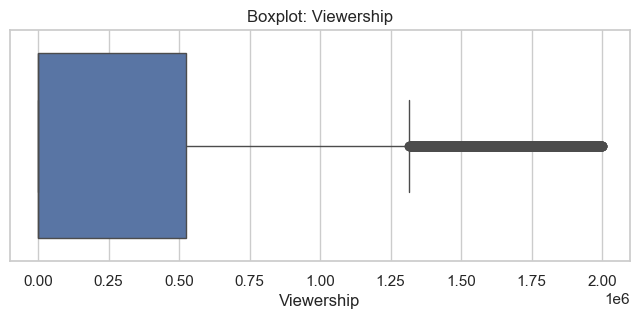

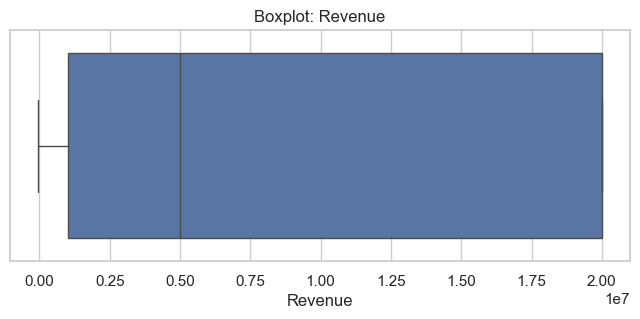

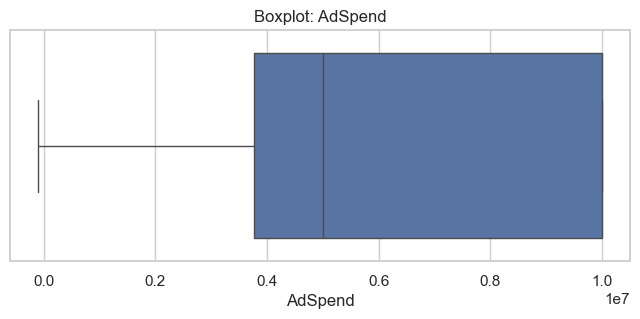

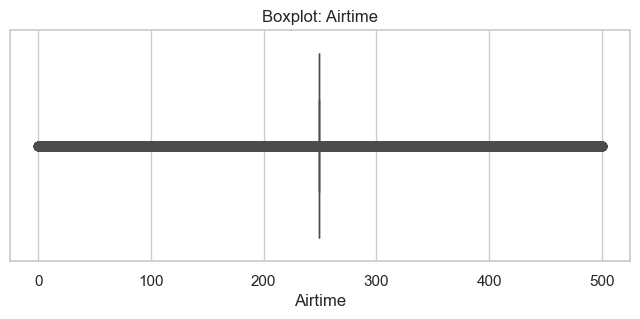

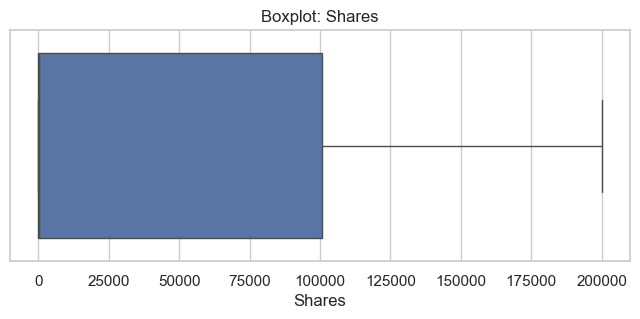

In [82]:
for col in ['Viewership','Revenue','AdSpend','Airtime','Shares']:
    if col in df.columns:
        plt.figure(figsize=(8,3))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot: {col}")
        plt.show()


## Quick EDA (Distribution + Correlation)

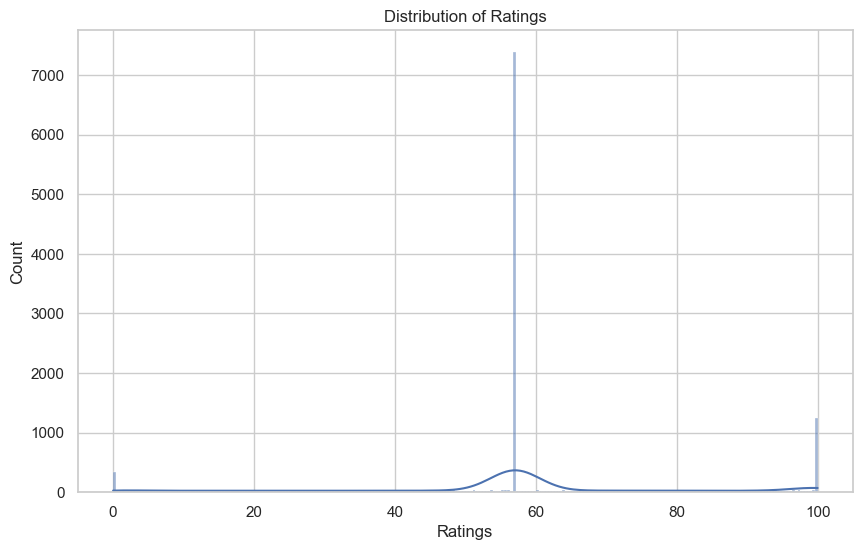

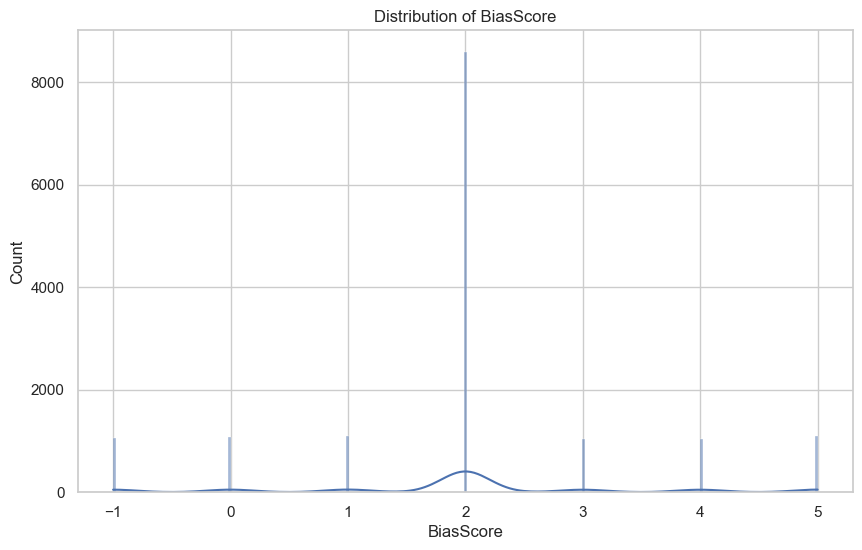

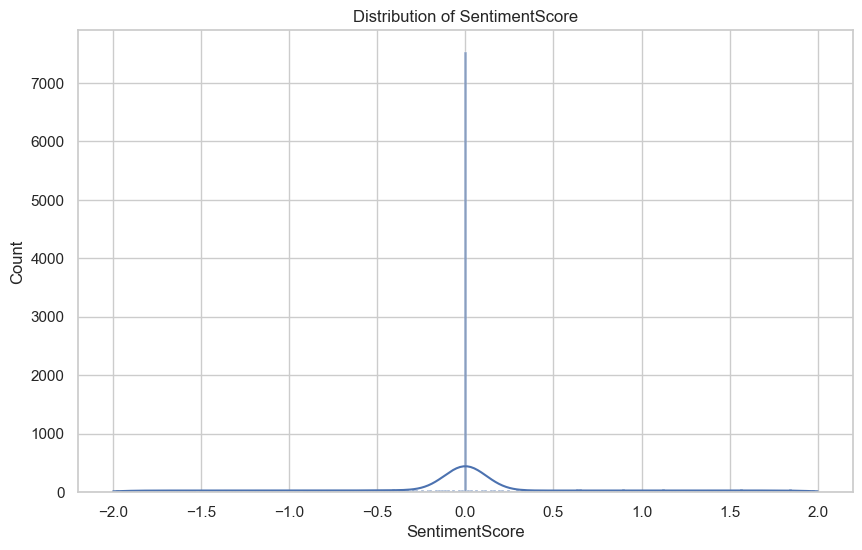

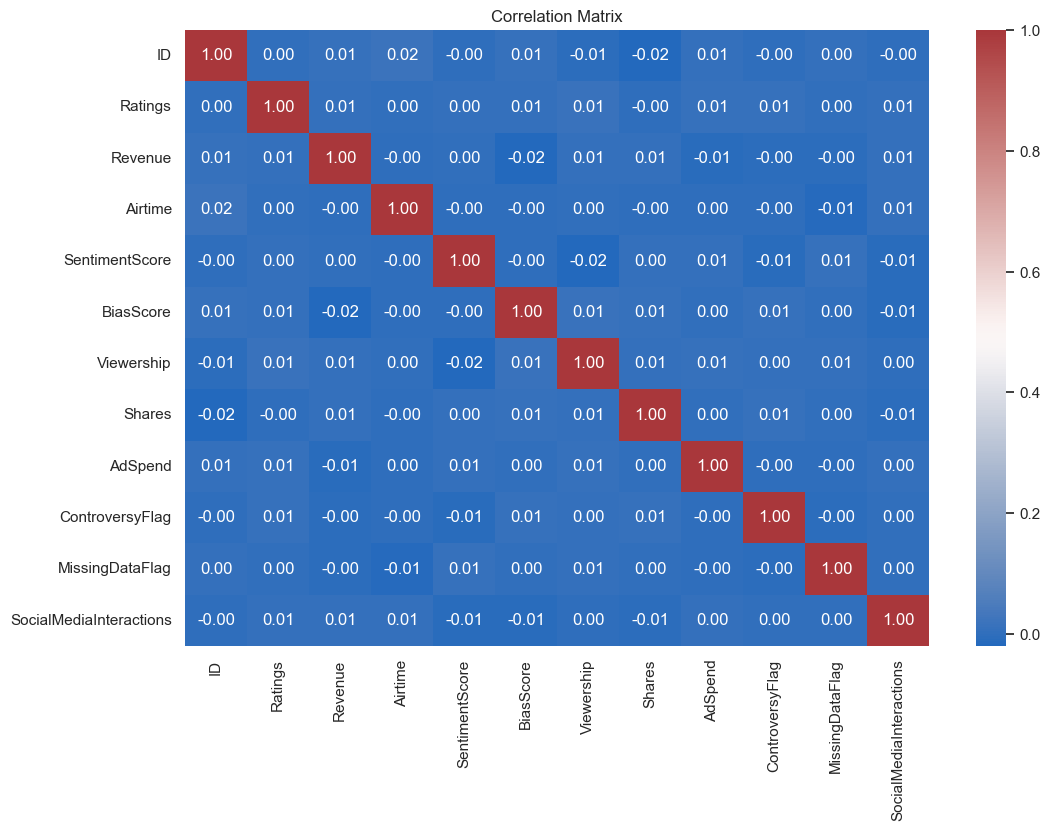

In [83]:

for col in ['Ratings','BiasScore','SentimentScore']:
    if col in df.columns:
        plt.figure()
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

num_df = df.select_dtypes(include=[np.number])
if not num_df.empty:
    plt.figure(figsize=(12,8))
    sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='vlag')
    plt.title("Correlation Matrix")
    plt.show()


## Topic Coverage Visualization

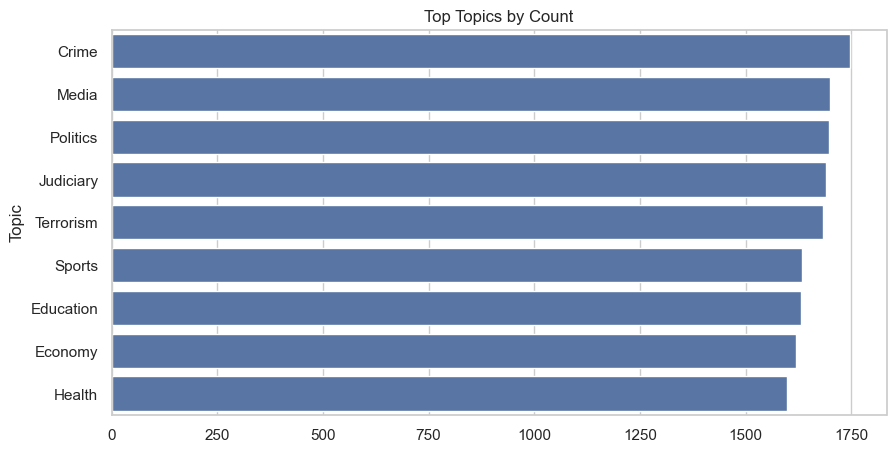

In [84]:
top_topics = df['Topic'].value_counts().head(15)
plt.figure(figsize=(10,5))
sns.barplot(x=top_topics.values, y=top_topics.index)
plt.title("Top Topics by Count")
plt.show()

## Bias vs Revenue Check

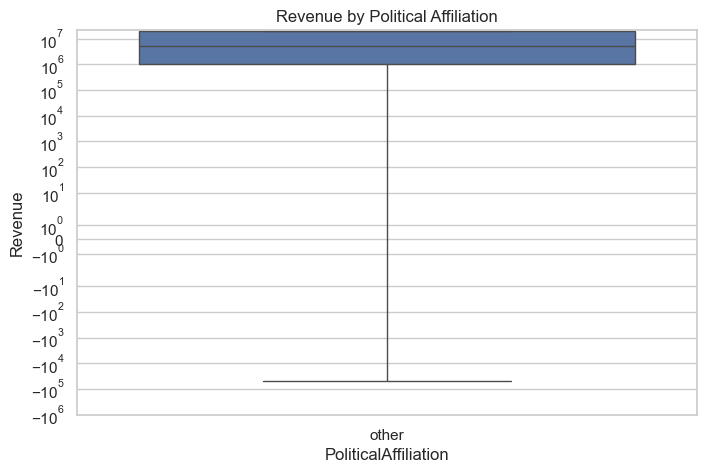

In [85]:
if 'PoliticalAffiliation' in df.columns and 'Revenue' in df.columns:
    def group_affil(x):
        if 'pro' in x and 'gov' in x: return 'pro-govt'
        elif 'opp' in x: return 'opposition'
        elif 'neutral' in x: return 'neutral'
        else: return 'other'
    df['PoliticalAffiliation'] = df['PoliticalAffiliation'].apply(group_affil)

    plt.figure(figsize=(8,5))
    sns.boxplot(x='PoliticalAffiliation', y='Revenue', data=df)
    plt.yscale('symlog')
    plt.title("Revenue by Political Affiliation")
    plt.show()

    pro = df[df['PoliticalAffiliation']=='pro-govt']['Revenue'].dropna()
    other = df[df['PoliticalAffiliation']!='pro-govt']['Revenue'].dropna()
    if len(pro)>10 and len(other)>10:
        stat, p = mannwhitneyu(pro, other, alternative='two-sided')
        print(f"Mann-Whitney test p-value: {p:.4f}")


## Final Check & Save Cleaned Dataset

In [86]:
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())
df.to_csv("pakistan-media-dataset-cleaned.csv", index=False)
print("Cleaned dataset saved.")

Final shape: (15000, 22)
Columns: ['ID', 'Journalist', 'Channel', 'Newspaper', 'Region', 'City', 'Topic', 'Headline', 'Ratings', 'Revenue', 'Airtime', 'SentimentScore', 'BiasScore', 'Viewership', 'Shares', 'AdSpend', 'ControversyFlag', 'MissingDataFlag', 'Date', 'Language', 'PoliticalAffiliation', 'SocialMediaInteractions']
Cleaned dataset saved.
